In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import pickle
plt.style.use(['science','no-latex'])
colors = ["#1982c4", "black", "#ff595e", "#20b806"]

In [3]:
def plot_free_energy(XDATA, YDATA, xlabel, ylabel, bins=20):
    temperature = 1.
    values, xedge, yedge = np.histogram2d(XDATA, YDATA, bins=bins)
    xs = xedge[:-1] + (xedge[1] - xedge[0]) / 2  # Calculate the center of each bin
    ys = yedge[:-1] + (yedge[1] - yedge[0]) / 2  # Calculate the center of each bin
    total = np.sum(values)
    values = values / total
    values_nan = np.where(values == 0, np.nan, values)
    free_ene = -np.log(values_nan) / temperature

    X, Y = np.meshgrid(xs, ys)
    plt.contourf(X, Y, free_ene.T, cmap='YlGnBu')
    plt.colorbar(label='free energy (KBT)')
    plt.contour(X, Y, free_ene.T, colors='k', linewidths=1)
    plt.plot(np.linspace(0, np.pi, 2), np.linspace(0, np.pi, 2),  "--", color="black")
    plt.xlim([0, np.pi])
    plt.ylim([0, np.pi])
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title('Free energy landscape')
    #plt.savefig('./images/long_simulation_st.png', transparent=True)
    plt.show()

def compute_IGs(imbalances, correction=True):    
    n_indep_realizations = imbalances.shape[0]
    n_taus = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_taus),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_taus),alphas_max] / np.sqrt(n_indep_realizations)

    if correction:
        IGs[imbalances[:,:,0].mean(axis=0) > 1] = 0
        errors[imbalances[:,:,0].mean(axis=0) > 1] = 0
        
    return IGs, errors

# 1) Asymmetric wells

In [10]:
def target_energy(xdata, ydata):
    gauss1 = 1/(2*np.pi) * np.exp(-0.5*((xdata)**2 + (ydata)**2))
    gauss2 = 1/(2*np.pi) * np.exp(-0.5*((xdata-5)**2 + (ydata-5)**2))
    gauss3 = 1/(2*np.pi) * np.exp(-0.5*((xdata-12)**2 + (ydata)**2)) # asymmetry along x!
    energy = -np.log(1/3*gauss1 + 1/3*gauss2 + 1/3*gauss3)
    return energy

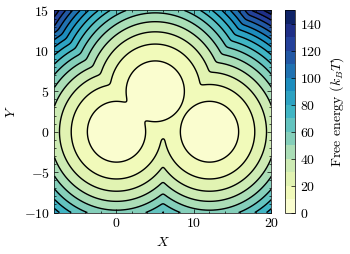

In [11]:
xdata, ydata = np.meshgrid(np.linspace(-8,20,1000), np.linspace(-10,15,1000), copy=True, sparse=False, indexing='xy')
free_ene = target_energy(xdata, ydata)

plt.contourf(xdata, ydata, free_ene, cmap='YlGnBu', levels=14)#, norm="log")
plt.colorbar(label='Free energy ($k_B T$)')
plt.contour(xdata, ydata, free_ene, colors='k', linewidths=1, levels=14)#, norm="log")
#plt.xlim([0, np.pi])
#plt.ylim([0, np.pi])
plt.xlabel("$X$")
plt.ylabel("$Y$")
plt.savefig('/scratch/vdeltatt/imbalance-gain-causality/langevin/figures/free_eng_3minima.pdf', transparent=True, dpi=300)
plt.show()

### 1.1) Transfer entropy

In [4]:
k = 7
N = 2500
taus = np.arange(10,770,40,dtype=int)
seeds = np.arange(20)

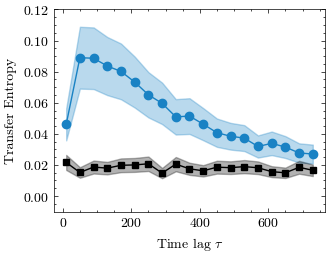

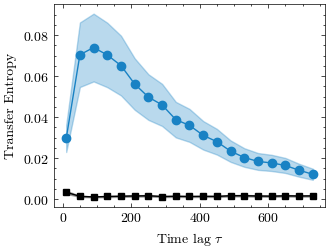

In [ ]:
TEs_X_to_Y = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X = np.zeros((len(seeds),len(taus)))
TEs_X_to_Y_discrete = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X_discrete = np.zeros((len(seeds),len(taus)))

for iseed, seed in enumerate(seeds):
    _, TEs_X_to_Y[iseed], TEs_Y_to_X[iseed], TEs_X_to_Y_discrete[iseed], TEs_Y_to_X_discrete[iseed] = (
        pickle.load(open(f"./asymmetric_energy_far/pickles_te/seed{seed}_N{N}_k{k}.p","rb"))
    )

# continuous
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y.mean(axis=0), TEs_X_to_Y.mean(axis=0) / np.sqrt(TEs_X_to_Y.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X.mean(axis=0), TEs_Y_to_X.mean(axis=0) / np.sqrt(TEs_Y_to_X.shape[0])
plt.plot(taus, avg_X_to_Y, 'o-', color=colors[0])
plt.plot(taus, avg_Y_to_X, 's-', color=colors[1], markersize=5)
plt.fill_between(taus, avg_X_to_Y-err_X_to_Y, avg_X_to_Y+err_X_to_Y, alpha=0.3, color=colors[0])
plt.fill_between(taus, avg_Y_to_X-err_Y_to_X, avg_Y_to_X+err_Y_to_X, alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Transfer Entropy")
plt.ylim([-0.01, 0.12])
#plt.legend()
#plt.savefig('./figures/TE_3minima_cont.pdf', transparent=True, dpi=300)
plt.show()

# discrete
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y_discrete.mean(axis=0), TEs_X_to_Y_discrete.mean(axis=0) / np.sqrt(TEs_X_to_Y_discrete.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X_discrete.mean(axis=0), TEs_Y_to_X_discrete.mean(axis=0) / np.sqrt(TEs_Y_to_X_discrete.shape[0])
plt.plot(taus, avg_X_to_Y, 'o-', color=colors[0])
plt.plot(taus, avg_Y_to_X, 's-', color=colors[1], markersize=5)
plt.fill_between(taus, avg_X_to_Y-err_X_to_Y, avg_X_to_Y+err_X_to_Y, alpha=0.3, color=colors[0])
plt.fill_between(taus, avg_Y_to_X-err_Y_to_X, avg_Y_to_X+err_Y_to_X, alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Transfer Entropy")
#plt.xlim([-5, 2000])
#plt.savefig('./figures/TE_3minima_discr.pdf', transparent=True, dpi=300)
plt.show()

Same but overlapping lagged mutual informations

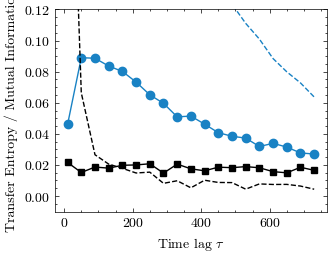

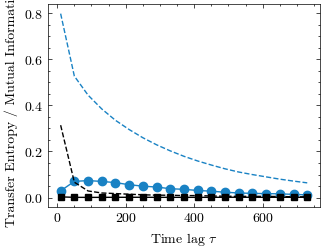

In [7]:
k = 7
N = 2500
taus = np.arange(10,770,40,dtype=int)
seeds = np.arange(20)

# read data
TEs_X_to_Y = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X = np.zeros((len(seeds),len(taus)))
TEs_X_to_Y_discrete = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X_discrete = np.zeros((len(seeds),len(taus)))
for iseed, seed in enumerate(seeds):
    _, TEs_X_to_Y[iseed], TEs_Y_to_X[iseed], TEs_X_to_Y_discrete[iseed], TEs_Y_to_X_discrete[iseed] = (
        pickle.load(open(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/asymmetric_energy_far/pickles_te/seed{seed}_N{N}_k{k}.p","rb"))
    )

MIs_X = np.zeros((len(seeds),len(taus)))
MIs_Y = np.zeros((len(seeds),len(taus)))
MIs_X_discrete = np.zeros((len(seeds),len(taus)))
MIs_Y_discrete = np.zeros((len(seeds),len(taus)))
for iseed, seed in enumerate(seeds):
    _, MIs_X[iseed], MIs_Y[iseed], MIs_X_discrete[iseed], MIs_Y_discrete[iseed] = (
        pickle.load(open(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/asymmetric_energy_far/pickles_mi/seed{seed}_N{N}_k{k}.p","rb"))
    )

# continuous
# transfer entropy
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y.mean(axis=0), TEs_X_to_Y.mean(axis=0) / np.sqrt(TEs_X_to_Y.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X.mean(axis=0), TEs_Y_to_X.mean(axis=0) / np.sqrt(TEs_Y_to_X.shape[0])
plt.plot(taus, avg_X_to_Y, 'o-', color=colors[0])
plt.plot(taus, avg_Y_to_X, 's-', color=colors[1], markersize=5)
# lagged mutual information
avg_X_to_Y, err_X_to_Y = MIs_X.mean(axis=0), MIs_X.mean(axis=0) / np.sqrt(MIs_X.shape[0])
avg_Y_to_X, err_Y_to_X = MIs_Y.mean(axis=0), MIs_Y.mean(axis=0) / np.sqrt(MIs_Y.shape[0])
plt.plot(taus, avg_X_to_Y, '--', color=colors[0])
plt.plot(taus, avg_Y_to_X, '--', color=colors[1], markersize=5)
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Transfer Entropy / Mutual Information")
plt.ylim([-0.01, 0.12])
#plt.legend()
#plt.savefig('./figures/TE_3minima_cont.pdf', transparent=True, dpi=300)
plt.show()

# discrete
# transfer entropy
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y_discrete.mean(axis=0), TEs_X_to_Y_discrete.mean(axis=0) / np.sqrt(TEs_X_to_Y_discrete.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X_discrete.mean(axis=0), TEs_Y_to_X_discrete.mean(axis=0) / np.sqrt(TEs_Y_to_X_discrete.shape[0])
plt.plot(taus, avg_X_to_Y, 'o-', color=colors[0])
plt.plot(taus, avg_Y_to_X, 's-', color=colors[1], markersize=5)
# lagged mutual information
avg_X_to_Y, err_X_to_Y = MIs_X_discrete.mean(axis=0), MIs_X_discrete.mean(axis=0) / np.sqrt(MIs_X_discrete.shape[0])
avg_Y_to_X, err_Y_to_X = MIs_Y_discrete.mean(axis=0), MIs_Y_discrete.mean(axis=0) / np.sqrt(MIs_Y_discrete.shape[0])
plt.plot(taus, avg_X_to_Y, '--', color=colors[0])
plt.plot(taus, avg_Y_to_X, '--', color=colors[1], markersize=5)
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Transfer Entropy / Mutual Information")
#plt.xlim([-5, 2000])
#plt.savefig('./figures/TE_3minima_discr.pdf', transparent=True, dpi=300)
plt.show()



### 1.2) Imbalance Gain

In [24]:
k = 25
taus = np.arange(10,770,40,dtype=int)
seeds = np.arange(20)
alphas = np.linspace(0,1,300)
N = 2500
imbs_X_to_Y = np.zeros((len(seeds), len(taus), len(alphas)))
imbs_Y_to_X = np.zeros((len(seeds), len(taus), len(alphas)))

for seed in seeds:
    taus, imbs_X_to_Y[seed], imbs_Y_to_X[seed] = pickle.load(open(f"./asymmetric_energy_far/pickles_imb/seed{seed}_N{N}_k{k}.p","rb"))

IGs_X_to_Y, errs_X_to_Y = compute_IGs(imbs_X_to_Y, correction=True)
IGs_Y_to_X, errs_Y_to_X = compute_IGs(imbs_Y_to_X, correction=True)

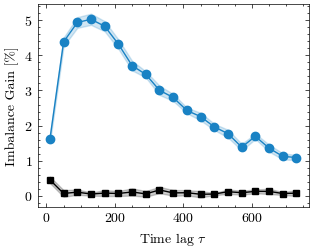

In [25]:
# x->y
plt.plot(taus, IGs_X_to_Y, 'o-', color=colors[0])#, label="X")#, 
plt.fill_between(taus, IGs_X_to_Y - errs_X_to_Y, IGs_X_to_Y + errs_X_to_Y, alpha=0.2, color=colors[0])
# y->x
plt.plot(taus, IGs_Y_to_X, 's-', color=colors[1], markersize=5)#, label="Y")#
plt.fill_between(taus, IGs_Y_to_X - errs_Y_to_X, IGs_Y_to_X + errs_Y_to_X, alpha=0.2, color=colors[1])
# labels
#plt.xticks(taus)
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Imbalance Gain [%]")
#plt.legend()
plt.savefig('./figures/IG_3minima.pdf', transparent=True, dpi=300)
plt.show()

### 1.3) Transfer entropy with inset for small taus, DISCRETE ESTIMATOR

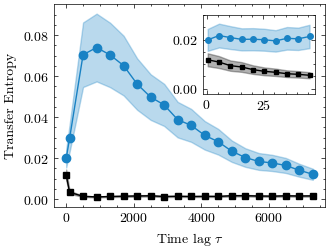

In [10]:
dir = '/scratch/vdeltatt/imbalance-gain-causality/langevin'

k = 7
N = 2500
taus = np.arange(10,770,40,dtype=int) * 10 # large taus are 100 times larger than small taus
taus_small = np.arange(5, 505, 25,dtype=int) / 10
seeds = np.arange(20)

TEs_X_to_Y_discrete = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X_discrete = np.zeros((len(seeds),len(taus)))
TEs_X_to_Y_discrete_small = np.zeros((len(seeds),len(taus_small)))
TEs_Y_to_X_discrete_small = np.zeros((len(seeds),len(taus_small)))

for iseed, seed in enumerate(seeds):
    _, _, _, TEs_X_to_Y_discrete[iseed], TEs_Y_to_X_discrete[iseed] = (
        pickle.load(open(dir + f"/asymmetric_energy_far/pickles_te/seed{seed}_N{N}_k{k}.p","rb"))
    )
    _, _, _, TEs_X_to_Y_discrete_small[iseed], TEs_Y_to_X_discrete_small[iseed] = (
        pickle.load(open(dir + f"/asymmetric_energy_far/small_lags/pickles_te/seed{seed}_N{N}_k{k}.p","rb"))
    )

# discrete
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y_discrete.mean(axis=0), TEs_X_to_Y_discrete.mean(axis=0) / np.sqrt(TEs_X_to_Y_discrete.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X_discrete.mean(axis=0), TEs_Y_to_X_discrete.mean(axis=0) / np.sqrt(TEs_Y_to_X_discrete.shape[0])
# inset
subsamples = np.arange(0,len(taus_small),2)
avg_X_to_Y_small, err_X_to_Y_small = TEs_X_to_Y_discrete_small.mean(axis=0), TEs_X_to_Y_discrete_small.mean(axis=0) / np.sqrt(TEs_X_to_Y_discrete_small.shape[0])
avg_Y_to_X_small, err_Y_to_X_small = TEs_Y_to_X_discrete_small.mean(axis=0), TEs_Y_to_X_discrete_small.mean(axis=0) / np.sqrt(TEs_Y_to_X_discrete_small.shape[0])

fig, ax1 = plt.subplots()
extended_taus = np.append(taus_small[0], taus)
extended_avg_X_to_Y = np.append(avg_X_to_Y_small[0], avg_X_to_Y)
extended_avg_Y_to_X = np.append(avg_Y_to_X_small[0], avg_Y_to_X)
extended_err_X_to_Y = np.append(err_X_to_Y_small[0], err_X_to_Y)
extended_err_Y_to_X = np.append(err_Y_to_X_small[0], err_Y_to_X)
ax1.plot(extended_taus, extended_avg_X_to_Y, 'o-', color=colors[0])
ax1.plot(extended_taus, extended_avg_Y_to_X, 's-', color=colors[1], markersize=5)
ax1.fill_between(extended_taus, extended_avg_X_to_Y-extended_err_X_to_Y, extended_avg_X_to_Y+extended_err_X_to_Y, alpha=0.3, color=colors[0])
ax1.fill_between(extended_taus, extended_avg_Y_to_X-extended_err_Y_to_X, extended_avg_Y_to_X+extended_err_Y_to_X, alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Transfer Entropy")


ax2 = fig.add_axes([0.55, 0.54, 0.32, 0.3])
plt.plot(taus_small[subsamples], avg_X_to_Y_small[subsamples], 'o-', color=colors[0], markersize=4)
plt.plot(taus_small[subsamples], avg_Y_to_X_small[subsamples], 's-', color=colors[1], markersize=3)
plt.fill_between(taus_small[subsamples], avg_X_to_Y_small[subsamples]-err_X_to_Y_small[subsamples], 
                 avg_X_to_Y_small[subsamples]+err_X_to_Y_small[subsamples], alpha=0.3, color=colors[0])
plt.fill_between(taus_small[subsamples], avg_Y_to_X_small[subsamples]-err_Y_to_X_small[subsamples], 
                 avg_Y_to_X_small[subsamples]+err_Y_to_X_small[subsamples], alpha=0.3, color=colors[1])
plt.ylim([-0.002, 0.03])
#plt.xticks(fontsize=9)
#plt.yticks(fontsize=9)
plt.savefig(dir + '/figures/TE_3minima_discr_inset.pdf', transparent=True, dpi=300)
plt.show()

### 1.3.2) Transfer entropy with inset for small taus, knncmi estimator, inset

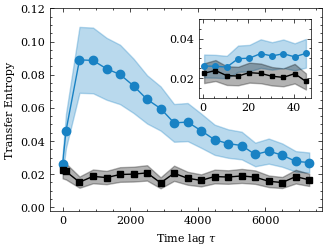

In [7]:
dir = '/scratch/vdeltatt/imbalance-gain-causality/langevin'
plt.rcParams.update({'font.size': 9})

k = 7
N = 2500
taus = np.arange(10,770,40,dtype=int) * 10 # large taus are 100 times larger than small taus
taus_small = np.arange(5, 505, 25,dtype=int) / 10
seeds = np.arange(20)

TEs_X_to_Y_discrete = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X_discrete = np.zeros((len(seeds),len(taus)))
TEs_X_to_Y_discrete_small = np.zeros((len(seeds),len(taus_small)))
TEs_Y_to_X_discrete_small = np.zeros((len(seeds),len(taus_small)))

for iseed, seed in enumerate(seeds):
    _, TEs_X_to_Y_discrete[iseed], TEs_Y_to_X_discrete[iseed], _, _ = (
        pickle.load(open(dir + f"/asymmetric_energy_far/pickles_te/seed{seed}_N{N}_k{k}.p","rb"))
    )
    _, TEs_X_to_Y_discrete_small[iseed], TEs_Y_to_X_discrete_small[iseed], _, _ = (
        pickle.load(open(dir + f"/asymmetric_energy_far/small_lags/pickles_te/seed{seed}_N{N}_k{k}.p","rb"))
    )

# discrete
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y_discrete.mean(axis=0), TEs_X_to_Y_discrete.mean(axis=0) / np.sqrt(TEs_X_to_Y_discrete.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X_discrete.mean(axis=0), TEs_Y_to_X_discrete.mean(axis=0) / np.sqrt(TEs_Y_to_X_discrete.shape[0])
# inset
subsamples = np.arange(0,len(taus_small),2)
avg_X_to_Y_small, err_X_to_Y_small = TEs_X_to_Y_discrete_small.mean(axis=0), TEs_X_to_Y_discrete_small.mean(axis=0) / np.sqrt(TEs_X_to_Y_discrete_small.shape[0])
avg_Y_to_X_small, err_Y_to_X_small = TEs_Y_to_X_discrete_small.mean(axis=0), TEs_Y_to_X_discrete_small.mean(axis=0) / np.sqrt(TEs_Y_to_X_discrete_small.shape[0])

fig, ax1 = plt.subplots()
extended_taus = np.append(taus_small[0], taus)
extended_avg_X_to_Y = np.append(avg_X_to_Y_small[0], avg_X_to_Y)
extended_avg_Y_to_X = np.append(avg_Y_to_X_small[0], avg_Y_to_X)
extended_err_X_to_Y = np.append(err_X_to_Y_small[0], err_X_to_Y)
extended_err_Y_to_X = np.append(err_Y_to_X_small[0], err_Y_to_X)
ax1.plot(extended_taus, extended_avg_X_to_Y, 'o-', color=colors[0])
ax1.plot(extended_taus, extended_avg_Y_to_X, 's-', color=colors[1], markersize=5)
ax1.fill_between(extended_taus, extended_avg_X_to_Y-extended_err_X_to_Y, extended_avg_X_to_Y+extended_err_X_to_Y, alpha=0.3, color=colors[0])
ax1.fill_between(extended_taus, extended_avg_Y_to_X-extended_err_Y_to_X, extended_avg_Y_to_X+extended_err_Y_to_X, alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
ax1.set(ylim=[-0.002,0.12])
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Transfer Entropy")

ax2 = fig.add_axes([0.55, 0.54, 0.32, 0.3])
plt.plot(taus_small[subsamples], avg_X_to_Y_small[subsamples], 'o-', color=colors[0], markersize=4)
plt.plot(taus_small[subsamples], avg_Y_to_X_small[subsamples], 's-', color=colors[1], markersize=3)
plt.fill_between(taus_small[subsamples], avg_X_to_Y_small[subsamples]-err_X_to_Y_small[subsamples], 
                 avg_X_to_Y_small[subsamples]+err_X_to_Y_small[subsamples], alpha=0.3, color=colors[0])
plt.fill_between(taus_small[subsamples], avg_Y_to_X_small[subsamples]-err_Y_to_X_small[subsamples], 
                 avg_Y_to_X_small[subsamples]+err_Y_to_X_small[subsamples], alpha=0.3, color=colors[1])
plt.ylim([0.01, 0.05])
#plt.xticks(fontsize=9)
#plt.yticks(fontsize=9)
plt.savefig(dir + '/figures/TE_3minima_cont_inset.pdf', transparent=True, dpi=300)
plt.show()

### 1.4) Imbalance Gain, small taus

In [11]:
k = 25
taus = np.arange(10,770,40,dtype=int) * 10 # taus of large timescales are 100 times larger than small taus
taus_small = np.arange(5, 505, 25,dtype=int) / 10
seeds = np.arange(20)
alphas = np.linspace(0,1,300)
N = 2500
imbs_X_to_Y = np.zeros((len(seeds), len(taus), len(alphas)))
imbs_Y_to_X = np.zeros((len(seeds), len(taus), len(alphas)))
imbs_X_to_Y_small = np.zeros((len(seeds), len(taus_small), len(alphas)))
imbs_Y_to_X_small = np.zeros((len(seeds), len(taus_small), len(alphas)))

for seed in seeds:
    _, imbs_X_to_Y[seed], imbs_Y_to_X[seed] = pickle.load(open(dir + f"/asymmetric_energy_far/pickles_imb/seed{seed}_N{N}_k{k}.p","rb"))
    _, imbs_X_to_Y_small[seed], imbs_Y_to_X_small[seed] = pickle.load(open(dir + f"/asymmetric_energy_far/small_lags/pickles_imb/seed{seed}_N{N}_k{k}.p","rb"))

IGs_X_to_Y, errs_X_to_Y = compute_IGs(imbs_X_to_Y, correction=True)
IGs_Y_to_X, errs_Y_to_X = compute_IGs(imbs_Y_to_X, correction=True)
IGs_X_to_Y_small, errs_X_to_Y_small = compute_IGs(imbs_X_to_Y_small, correction=True)
IGs_Y_to_X_small, errs_Y_to_X_small = compute_IGs(imbs_Y_to_X_small, correction=True)

extended_taus = np.append(taus_small[1], taus)
extended_IGs_X_to_Y = np.append(IGs_X_to_Y_small[1], IGs_X_to_Y)
extended_errs_X_to_Y = np.append(errs_X_to_Y_small[1], errs_X_to_Y)
extended_IGs_Y_to_X = np.append(IGs_Y_to_X_small[1], IGs_Y_to_X)
extended_errs_Y_to_X = np.append(errs_Y_to_X_small[1], errs_Y_to_X)

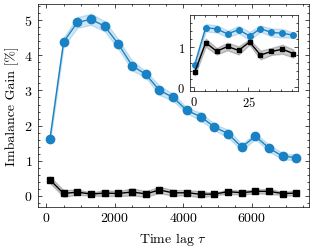

In [12]:
fig, ax1 = plt.subplots()

# x->y
ax1.plot(taus, IGs_X_to_Y, 'o-', color=colors[0])#, label="X")
ax1.fill_between(taus, IGs_X_to_Y - errs_X_to_Y, IGs_X_to_Y + errs_X_to_Y, alpha=0.2, color=colors[0])
# y->x
ax1.plot(taus, IGs_Y_to_X, 's-', color=colors[1], markersize=5)#, label="Y")
ax1.fill_between(taus, IGs_Y_to_X - errs_Y_to_X, IGs_Y_to_X + errs_Y_to_X, alpha=0.2, color=colors[1])
# labels

#inset
subsamples = np.arange(0,len(taus_small),2)
ax2 = fig.add_axes([0.56, 0.55, 0.31, 0.29])
# x->y
ax2.plot(taus_small[subsamples], IGs_X_to_Y_small[subsamples], 'o-', color=colors[0], markersize=4)
ax2.fill_between(taus_small[subsamples], IGs_X_to_Y_small[subsamples] - errs_X_to_Y_small[subsamples], 
                 IGs_X_to_Y_small[subsamples] + errs_X_to_Y_small[subsamples], alpha=0.2, color=colors[0])
# y->x
ax2.plot(taus_small[subsamples], IGs_Y_to_X_small[subsamples], 's-', color=colors[1], markersize=3)
ax2.fill_between(taus_small[subsamples], IGs_Y_to_X_small[subsamples] - errs_Y_to_X_small[subsamples], 
                 IGs_Y_to_X_small[subsamples] + errs_Y_to_X_small[subsamples], alpha=0.2, color=colors[1])
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax1.set(xlabel="Time lag $\\tau$", ylabel="Imbalance Gain [%]")
ax2.set(ylim=[-0.1,1.8])
#plt.savefig(dir + '/figures/IG_3minima_inset.pdf', transparent=True, dpi=300)
plt.show()

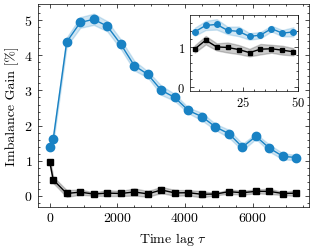

In [13]:
fig, ax1 = plt.subplots()

# x->y
ax1.plot(extended_taus, extended_IGs_X_to_Y, 'o-', color=colors[0])#, label="X")
ax1.fill_between(extended_taus, extended_IGs_X_to_Y - extended_errs_X_to_Y, extended_IGs_X_to_Y + extended_errs_X_to_Y, alpha=0.2, color=colors[0])
# y->x
ax1.plot(extended_taus, extended_IGs_Y_to_X, 's-', color=colors[1], markersize=5)#, label="Y")
ax1.fill_between(extended_taus, extended_IGs_Y_to_X - extended_errs_Y_to_X, extended_IGs_Y_to_X + extended_errs_Y_to_X, alpha=0.2, color=colors[1])
# labels

#inset
subsamples = np.arange(1,len(taus_small),2)
ax2 = fig.add_axes([0.56, 0.55, 0.31, 0.29])
# x->y
ax2.plot(taus_small[subsamples], IGs_X_to_Y_small[subsamples], 'o-', color=colors[0], markersize=4)
ax2.fill_between(taus_small[subsamples], IGs_X_to_Y_small[subsamples] - errs_X_to_Y_small[subsamples], 
                 IGs_X_to_Y_small[subsamples] + errs_X_to_Y_small[subsamples], alpha=0.2, color=colors[0])
# y->x
ax2.plot(taus_small[subsamples], IGs_Y_to_X_small[subsamples], 's-', color=colors[1], markersize=3)
ax2.fill_between(taus_small[subsamples], IGs_Y_to_X_small[subsamples] - errs_Y_to_X_small[subsamples], 
                 IGs_Y_to_X_small[subsamples] + errs_Y_to_X_small[subsamples], alpha=0.2, color=colors[1])
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax1.set(xlabel="Time lag $\\tau$", ylabel="Imbalance Gain [%]")
ax2.set(ylim=[-0.1,1.8])
plt.savefig(dir + '/figures/IG_3minima_inset.pdf', transparent=True, dpi=300)
plt.show()

## 2) Symmetric well, with nonzero cross correlation

In [6]:
def target_energy(xdata, ydata):
    cov = np.array([[1,0.6],[0.6,1]])
    inv_cov = np.linalg.inv(cov)
    prod = xdata * xdata * inv_cov[0,0] + 2 * xdata * ydata * inv_cov[0,1] + ydata * ydata * inv_cov[1,1]
    prob = 1/(2*np.pi) * np.exp(-0.5*prod)
    energy = -np.log(prob)

    return energy

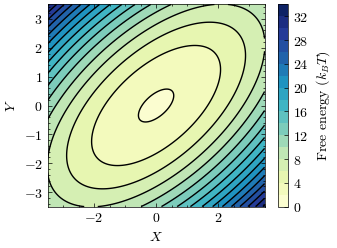

In [9]:
xdata, ydata = np.meshgrid(np.linspace(-3.5,3.5,1000), np.linspace(-3.5,3.5,1000), copy=True, sparse=False, indexing='xy')
free_ene = target_energy(xdata, ydata)

plt.contourf(xdata, ydata, free_ene, cmap='YlGnBu', levels=15)#, norm="log")
plt.colorbar(label='Free energy ($k_B T$)')
plt.contour(xdata, ydata, free_ene, colors='k', linewidths=1, levels=15)#, norm="log")
#plt.xlim([0, np.pi])
#plt.ylim([0, np.pi])
plt.xlabel("$X$")
plt.ylabel("$Y$")
#plt.savefig('/scratch/vdeltatt/imbalance-gain-causality/langevin/figures/free_eng_gaussian.pdf', transparent=True, dpi=300)
plt.show()


### 2.1) Transfer entropy

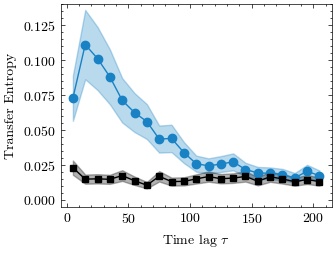

In [28]:
k = 7
taus = np.arange(5,215,10,dtype=int)
seeds = np.arange(20)

TEs_X_to_Y = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X = np.zeros((len(seeds),len(taus)))

for iseed, seed in enumerate(seeds):
    _, TEs_X_to_Y[iseed], TEs_Y_to_X[iseed] = (
        pickle.load(open(f"./gaussian_skewed/pickles_te/seed{seed}_N{2500}_k{k}.p","rb"))
    )
# continuous
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y.mean(axis=0), TEs_X_to_Y.mean(axis=0) / np.sqrt(TEs_X_to_Y.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X.mean(axis=0), TEs_Y_to_X.mean(axis=0) / np.sqrt(TEs_Y_to_X.shape[0])

plt.plot(taus, avg_X_to_Y, 'o-', color=colors[0])
plt.plot(taus, avg_Y_to_X, 's-', color=colors[1], markersize=5)
plt.fill_between(taus, avg_X_to_Y-err_X_to_Y, avg_X_to_Y+err_X_to_Y, alpha=0.3, color=colors[0])
plt.fill_between(taus, avg_Y_to_X-err_Y_to_X, avg_Y_to_X+err_Y_to_X, alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Transfer Entropy")
plt.ylim([-0.005, 0.140])
#plt.legend()
plt.savefig('./figures/TE_gaussian.pdf', transparent=True, dpi=300)
plt.show()

Same but overlapping lagged mutual informations

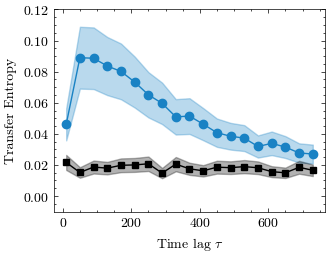

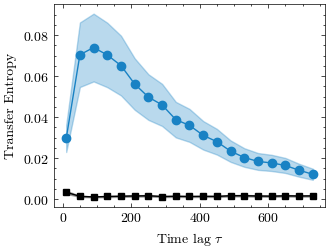

In [ ]:
k = 7
N = 2500
taus = np.arange(5,215,10,dtype=int)
seeds = np.arange(20)

# read data
TEs_X_to_Y = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X = np.zeros((len(seeds),len(taus)))
for iseed, seed in enumerate(seeds):
    _, TEs_X_to_Y[iseed], TEs_Y_to_X[iseed] = (
        pickle.load(open(f"./gaussian_skewed/pickles_te/seed{seed}_N{N}_k{k}.p","rb"))
    )

MIs_X = np.zeros((len(seeds),len(taus)))
MIs_Y = np.zeros((len(seeds),len(taus)))
for iseed, seed in enumerate(seeds):
    _, MIs_X[iseed], MIs_Y[iseed] = (
        pickle.load(open(f"./gaussian_skewed/pickles_mi/seed{seed}_N{N}_k{k}.p","rb"))
    )

# continuous
# transfer entropy
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y.mean(axis=0), TEs_X_to_Y.mean(axis=0) / np.sqrt(TEs_X_to_Y.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X.mean(axis=0), TEs_Y_to_X.mean(axis=0) / np.sqrt(TEs_Y_to_X.shape[0])
plt.plot(taus, avg_X_to_Y, 'o-', color=colors[0])
plt.plot(taus, avg_Y_to_X, 's-', color=colors[1], markersize=5)
# lagged mutual information
avg_X_to_Y, err_X_to_Y = MIs_X.mean(axis=0), MIs_X.mean(axis=0) / np.sqrt(MIs_X.shape[0])
avg_Y_to_X, err_Y_to_X = MIs_Y.mean(axis=0), MIs_Y.mean(axis=0) / np.sqrt(MIs_Y.shape[0])
plt.plot(taus, avg_X_to_Y, '--', color=colors[0])
plt.plot(taus, avg_Y_to_X, '--', color=colors[1], markersize=5)
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Transfer Entropy / Mutual Information")
plt.ylim([-0.005, 0.140])
#plt.legend()
#plt.savefig('./figures/TE_3minima_cont.pdf', transparent=True, dpi=300)
plt.show()

### 2.2) Imbalance Gain

In [14]:
k = 25
taus = np.arange(5,215,10,dtype=int)
seeds = np.arange(20)
alphas = np.linspace(0,1,300)
N = 2500
imbs_X_to_Y = np.zeros((len(seeds), len(taus), len(alphas)))
imbs_Y_to_X = np.zeros((len(seeds), len(taus), len(alphas)))

for seed in seeds:
    taus, imbs_X_to_Y[seed], imbs_Y_to_X[seed] = pickle.load(open(f"./gaussian_skewed/pickles_imb/seed{seed}_N{N}_k{k}.p","rb"))

IGs_X_to_Y, errs_X_to_Y = compute_IGs(imbs_X_to_Y, correction=True)
IGs_Y_to_X, errs_Y_to_X = compute_IGs(imbs_Y_to_X, correction=True)

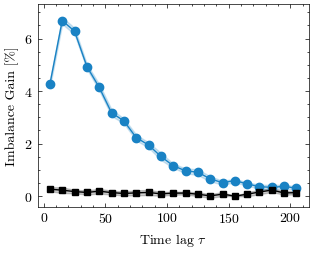

In [20]:
# x->y
plt.plot(taus, IGs_X_to_Y, 'o-', color=colors[0])
plt.fill_between(taus, IGs_X_to_Y - errs_X_to_Y, IGs_X_to_Y + errs_X_to_Y, alpha=0.2, color=colors[0])
# y->x
plt.plot(taus, IGs_Y_to_X, 's-', color=colors[1], markersize=5)
plt.fill_between(taus, IGs_Y_to_X - errs_Y_to_X, IGs_Y_to_X + errs_Y_to_X, alpha=0.2, color=colors[1])
# labels
#plt.xticks(taus)
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Imbalance Gain [%]")
#plt.legend()
plt.ylim([-0.4,7.3])
#plt.savefig('./figures/IG_gaussian.pdf', transparent=True, dpi=300)
plt.show()

### 2.3) Transfer entropy, no diff in autocorr

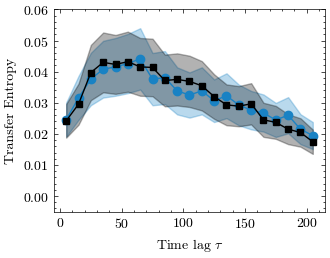

In [8]:
k = 7
taus = np.arange(5,215,10,dtype=int)
seeds = np.arange(20)

TEs_X_to_Y = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X = np.zeros((len(seeds),len(taus)))

for iseed, seed in enumerate(seeds):
    _, TEs_X_to_Y[iseed], TEs_Y_to_X[iseed] = (
        pickle.load(open(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/gaussian_skewed_nodiff/pickles_te/seed{seed}_N{2500}_k{k}.p","rb"))
    )
# continuous
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y.mean(axis=0), TEs_X_to_Y.mean(axis=0) / np.sqrt(TEs_X_to_Y.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X.mean(axis=0), TEs_Y_to_X.mean(axis=0) / np.sqrt(TEs_Y_to_X.shape[0])

plt.plot(taus, avg_X_to_Y, 'o-', color=colors[0])
plt.plot(taus, avg_Y_to_X, 's-', color=colors[1], markersize=5)
plt.fill_between(taus, avg_X_to_Y-err_X_to_Y, avg_X_to_Y+err_X_to_Y, alpha=0.3, color=colors[0])
plt.fill_between(taus, avg_Y_to_X-err_Y_to_X, avg_Y_to_X+err_Y_to_X, alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Transfer Entropy")
plt.ylim([-0.005, 0.06])
#plt.legend()
plt.savefig('/scratch/vdeltatt/imbalance-gain-causality/langevin/figures/TE_gaussian_nodiff.pdf', transparent=True, dpi=300)
plt.show()

### 2.4) Imbalance Gain, no diff in autocorr

In [11]:
k = 25
taus = np.arange(5,215,10,dtype=int)
seeds = np.arange(20)
alphas = np.linspace(0,1,300)
N = 2500
imbs_X_to_Y = np.zeros((len(seeds), len(taus), len(alphas)))
imbs_Y_to_X = np.zeros((len(seeds), len(taus), len(alphas)))

for seed in seeds:
    taus, imbs_X_to_Y[seed], imbs_Y_to_X[seed] = pickle.load(open(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/gaussian_skewed_nodiff/pickles_imb/seed{seed}_N{N}_k{k}.p","rb"))

IGs_X_to_Y, errs_X_to_Y = compute_IGs(imbs_X_to_Y, correction=True)
IGs_Y_to_X, errs_Y_to_X = compute_IGs(imbs_Y_to_X, correction=True)

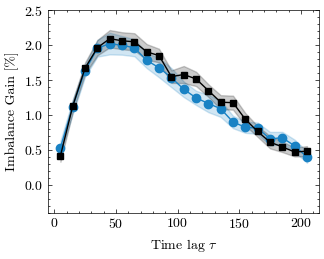

In [13]:
# x->y
plt.plot(taus, IGs_X_to_Y, 'o-', color=colors[0])
plt.fill_between(taus, IGs_X_to_Y - errs_X_to_Y, IGs_X_to_Y + errs_X_to_Y, alpha=0.2, color=colors[0])
# y->x
plt.plot(taus, IGs_Y_to_X, 's-', color=colors[1], markersize=5)
plt.fill_between(taus, IGs_Y_to_X - errs_Y_to_X, IGs_Y_to_X + errs_Y_to_X, alpha=0.2, color=colors[1])
# labels
#plt.xticks(taus)
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Imbalance Gain [%]")
#plt.legend()
plt.ylim([-0.4,2.5])
plt.savefig('/scratch/vdeltatt/imbalance-gain-causality/langevin/figures/IG_gaussian_nodiff.pdf', transparent=True, dpi=300)
plt.show()

# 3) Markov system

### 3.1) Transfer entropy

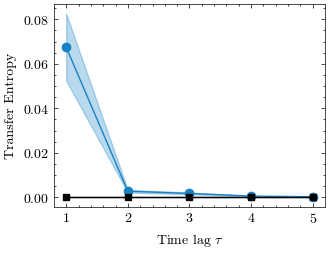

In [36]:
k = 7
taus, TEs_X_to_Y, TEs_Y_to_X = pickle.load(open("../markov/pickles_te/allseeds.p","rb"))
ntrajs = TEs_X_to_Y.shape[0]

# continuous
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y.mean(axis=0), TEs_X_to_Y.mean(axis=0) / np.sqrt(TEs_X_to_Y.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X.mean(axis=0), TEs_Y_to_X.mean(axis=0) / np.sqrt(TEs_Y_to_X.shape[0])

last_lag = 5
plt.plot(taus[:last_lag], avg_X_to_Y[:last_lag], 'o-', color=colors[0])#, label="ref dipole $\\rightarrow $ 1st shell")
plt.plot(taus[:last_lag], avg_Y_to_X[:last_lag], 's-', color=colors[1], markersize=5)#, label="1st shell $\\rightarrow $ ref dipole")
plt.fill_between(taus[:last_lag], avg_X_to_Y[:last_lag]-err_X_to_Y[:last_lag], avg_X_to_Y[:last_lag]+err_X_to_Y[:last_lag], alpha=0.3, color=colors[0])
plt.fill_between(taus[:last_lag], avg_Y_to_X[:last_lag]-err_Y_to_X[:last_lag], avg_Y_to_X[:last_lag]+err_Y_to_X[:last_lag], alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[last_lag-1], linestyle="--", color="black")
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Transfer Entropy")
#plt.xlim([-5, 2000])
#plt.legend()
plt.savefig('./figures/TE_markov.pdf', transparent=True, dpi=300)
plt.show()

### 2.2) Imbalance Gain

In [37]:
k = 25
taus = np.arange(1,11,dtype=int)
seeds = np.arange(20)
alphas = np.linspace(0,20,500)
N = 2500
imbs_X_to_Y = np.zeros((len(seeds), len(taus), len(alphas)))
imbs_Y_to_X = np.zeros((len(seeds), len(taus), len(alphas)))

for seed in seeds:
    taus, alphas, imbs_X_to_Y[seed], imbs_Y_to_X[seed] = pickle.load(open(f"../markov/pickles_ig/seed{seed}_k{k}.p","rb"))

IGs_X_to_Y, errs_X_to_Y = compute_IGs(imbs_X_to_Y, correction=True)
IGs_Y_to_X, errs_Y_to_X = compute_IGs(imbs_Y_to_X, correction=True)

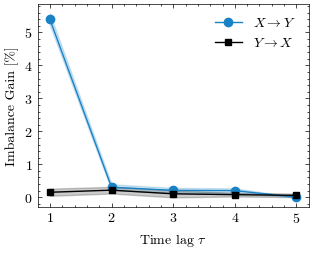

In [39]:
last_lag = 5

# x->y
plt.plot(taus[:last_lag], IGs_X_to_Y[:last_lag], 'o-', label="$X \\rightarrow Y$", color=colors[0])
plt.fill_between(taus[:last_lag], IGs_X_to_Y[:last_lag] - errs_X_to_Y[:last_lag], IGs_X_to_Y[:last_lag] + errs_X_to_Y[:last_lag], alpha=0.2, color=colors[0])
# y->x
plt.plot(taus[:last_lag], IGs_Y_to_X[:last_lag], 's-', label="$Y \\rightarrow X$", color=colors[1], markersize=5)
plt.fill_between(taus[:last_lag], IGs_Y_to_X[:last_lag] - errs_Y_to_X[:last_lag], IGs_Y_to_X[:last_lag] + errs_Y_to_X[:last_lag], alpha=0.2, color=colors[1])
# labels
#plt.xticks(taus)
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Imbalance Gain [%]")
plt.legend()
plt.savefig('./figures/IG_markov.pdf', transparent=True, dpi=300)
plt.show()

In [1]:
# try knncmi library

In [14]:
import numpy as np
from sklearn.feature_selection import mutual_info_regression

variable_names = ['x_0', 'y_0', 'x_tau', 'y_tau']
X0 = np.random.normal(size=(1000,))
Y0 = np.random.normal(size=(1000,))
Xtau = np.random.normal(size=(1000,))
Ytau = np.random.normal(size=(1000,))

# compute (continuous) transfer entropy in both directions
prova = mutual_info_regression(X0.reshape((-1,1)), X0, n_neighbors=3)
print(prova)


[5.65113753]


In [19]:
from pyitlib import discrete_random_variable as drv

X0 = np.ones((1000,))
Y0 =+ X0
X0[np.random.choice(np.arange(1000), size=(500,), replace=False)] = 0
Y0[np.random.choice(np.arange(1000), size=(500,), replace=False)] = 0

drv.information_mutual(X0,Y0)

0.0007387859772158833